In [3]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from concurrent.futures import ProcessPoolExecutor, as_completed

from scipy.signal import butter, filtfilt
from scipy.stats import skew, kurtosis

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Setup

## 1. DEAP

### 1.1 Locate and Unzip

In [4]:
target_dir = None if os.path.exists("./deap-dataset") else '/content/gdrive/MyDrive/'
dataset_dir = "./deap-dataset" if os.path.exists("./deap-dataset") else f"{target_dir}/deap-dataset"

In [5]:
# Mount google drive directory
if target_dir is not None:
    from google.colab import drive
    import requests

    drive.mount('/content/gdrive/')

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).


In [6]:
if target_dir is not None and os.path.exists(target_dir):
    os.chdir(target_dir)
    print(f"Changed directory to: {os.getcwd()}")

elif target_dir is not None:
    print(f"Error: Directory not found: {target_dir}. Please ensure Google Drive is mounted and the path is correct.")
    exit(1)

if not os.path.exists(dataset_dir):
    os.system(f"unzip deap-dataset.zip -d {dataset_dir}")
    print("deap-dataset.zip extracted.")

else:
    print("deap-dataset directory already exists. Skipping extraction.")

Changed directory to: /content/gdrive/MyDrive
deap-dataset directory already exists. Skipping extraction.


The `deap-dataset.zip` archive has been extracted, creating a directory named `deap-dataset/` which contains all the dataset files and subdirectories, including `data_preprocessed_python/`.

### 1.2 load sub

The videos are in the order of Experiment_id, so not in the order of presentation. This means the first video is the same for each participant.

In [7]:
target_dir = 'deap-dataset/data_preprocessed_python/'

In [8]:
if os.path.exists(target_dir):
    os.chdir(target_dir)
    print(f"Changed directory to: {os.getcwd()}")

else:
    print(f"Error: Directory not found: {os.path.join(os.getcwd(), target_dir)}. Please ensure 'deap-dataset.zip' was extracted correctly and contains 'data_preprocessed_python/'.")

Changed directory to: /content/gdrive/MyDrive/deapp/data_preprocessed_python


We've now navigated into the `deap-dataset/data_preprocessed_python/` directory, where the individual subject data files (`sXX.dat`) are located.

In [9]:
def load_subjects_data(subject_id_str):
  """Loads data for a specific subject from a .dat file."""

  file_name = f's{subject_id_str}.dat'

  with open(file_name, 'rb') as file:
    subject = pickle.load(file, encoding='latin1')

  return subject

In [10]:
# Example usage: Load data for subject '01'

subject_id = '01'
subject = load_subjects_data(subject_id)

print(f"Successfully loaded data for subject {subject_id}.")

Successfully loaded data for subject 01.


In [11]:
subject.keys()

dict_keys(['labels', 'data'])

The `subject` dictionary contains two main keys: 'labels' and 'data'.

*   **'labels'**: This typically contains the self-assessment scores (valence, arousal, dominance, liking) for each video watched by the participant.
*   **'data'**: This holds the physiological signal data (e.g., EEG, EOG, EMG, GSR, respiration, temperature) recorded during the experiment.

In [12]:
subject['data'].shape

(40, 40, 8064)

The shape of $\text{subject}[\text{data}]$ is $(40, 40, 8064)$:

*   $40$: Represents the $40$ experimental trials (videos) for this participant.
*   $40$: Represents the $40$ physiological channels (e.g., $32$ EEG, $8$ peripheral).
*   $8064$: Represents the number of data points (samples) per channel per trial. Given a sampling rate of $128\ \text{Hz}$ and a trial duration of $63$ seconds, this corresponds to $128 \text{ samples/second} * 63 \text{ seconds} = 8064 \text{ samples}$.

In [13]:
subject['labels'].shape

(40, 4)

The shape of $\text{subject}[\text{labels}]$ is $(40, 4)$:

*   $40$: Represents the 40 experimental trials (videos).
*   $4$: Represents the 4 self-assessment scores: Valence, Arousal, Dominance, and Liking, typically rated on a scale of 1-9.

### 1.3. Cache into memory

In [14]:
global subject_data
subjects_data = []

global subject_labels
subjects_labels = []

In [15]:
for subject in range(1, 33):
    filename = f"s{subject:02d}.dat"
    try:
        # Open binary file
        with open(filename, "rb") as f:
            dataset = pickle.load(f, encoding="latin1")

        # load features
        subjects_data.append(dataset["data"])

        # load labels
        subjects_labels.append(dataset["labels"])

    except (EOFError, pickle.UnpicklingError, OSError) as e:
        print(f"WARNING: skipping s{subject:02d}.dat (corrupted: {e})")
        continue

In [16]:
print(f"Cached {len(subjects_data)} subjects successfully.")

Cached 26 subjects successfully.


## 3. Plotting

In [17]:
def plot_classifier_metrics(*rows, title="Classifier Comparison") -> None:
    def _resolve_name(r):
        idx = r[1]
        if isinstance(idx, str):
            return idx

        else:
            return classifier_labels[idx - 1]


    names = [_resolve_name(r) for r in rows]

    metrics = {
        "Accuracy": [r[2] for r in rows],
        "Precision": [r[3] for r in rows],
        "Recall": [r[4] for r in rows],
        "F1": [r[5] for r in rows],
    }

    x = np.arange(len(rows))
    width = 0.2

    plt.figure(figsize=(10, 5))

    for i, (metric, values) in enumerate(metrics.items()):
        plt.bar(x + i * width, values, width=width, label=metric)

    plt.xticks(x + width * 1.5, names)
    plt.title(title)
    plt.xlabel("Classifier")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.show()

# Settings

All global constants and variables used

`Fs`: sampling rate/frequency ($128\ \text{Hz}$).

In [18]:
Fs = 128 # Hz

`label_column`: zero-based index of self-assessment scores to classify ($ 0 = \text{Valence} $).

In [19]:
label_column = 0

`segment_length`: each $60\large s$ trial is split into four $15\large s$ windows.

In [20]:
segment_length = 15 * Fs

`b, a`: 4th-order Butterworth band-pass filter (0.5–45 Hz), the typical EEG range.

In [21]:
b, a = butter(
    4, # 4th-order
    [0.5/(Fs/2), 45/(Fs/2)], # [0.5–45 Hz], Typical EEG range
    btype='bandpass'
)

Labels and shared accumulator for the comparison table at the end.

In [22]:
global results
results = []

global segment_splits
segment_splits = []

global Xtrain, Xtest
global Ytrain, Ytest

In [23]:
classifier_labels = [
    "SVM",
    "KNN",
    "Logistic Regression",
    "Decision Tree",
    "LDA"
]

segment_labels = [
    "0-15 s",
    "15-30 s",
    "30-45 s",
    "45-60 s"
]

# Pre-processing

### Dimensionality Reduction & Train/Test Split

PCA reduces the feature space to $20$ components before classification, to ease the curse of dimensionality. The reduced data is then split $70/30$ into train and test sets, stratified by label so both sets keep the same class balance.

In [24]:
def run_pca(X, n_comp=20) -> np.array:
    pca_model = PCA(n_components=n_comp)
    X = pca_model.fit_transform(X)

    print(f"PCA explained variance retained: {pca_model.explained_variance_ratio_.sum():.4f}")

    return X

In [25]:
def run_split_traintest(X_red, Y) -> tuple:
    """Splits train and test data from normalised dataset"""

    Xtrain, Xtest, Ytrain, Ytest = train_test_split(
        X_red, Y, test_size=0.30, random_state=42, stratify=Y
    )

    return Xtrain, Xtest, Ytrain, Ytest

### Feature Extraction

For a single trial, `runTrial()`:

1. Band-pass filters all 32 EEG channels (using the filter defined in Settings).
2. Keeps only the current 15-second segment.
3. Computes 6 statistical features per channel — mean, std, variance, RMS, skewness, kurtosis.

It returns the resulting feature vector together with the trial's label, and relies on `data`, `trial`, `segment`, and `current_labels` being set by the loop that calls it.

In [26]:
def runTrial(trial, data, segment, current_labels) -> tuple:
    eeg = data[trial, 0:32, :]

    # Bandpass filter: 0.5-45 Hz, 4th-order Butterworth
    eeg_filt = np.zeros_like(eeg)
    for ch in range(32):
        eeg_filt[ch, :] = filtfilt(b, a, eeg[ch, :])


    # Slice current segment
    start_idx = segment * segment_length
    end_idx = (segment + 1) * segment_length
    eeg_seg = eeg_filt[:, start_idx:end_idx]


    # Extract 6 statistical features per channel
    feature_vector = []
    for ch in range(32):
        x = eeg_seg[ch, :]

        feature_vector.extend([
            np.mean(x),
            np.std(x),
            np.var(x),
            np.sqrt(np.mean(x**2)),
            skew(x),
            kurtosis(x)
        ])


    return feature_vector, current_labels[trial]

### Main loop

For each of the $4$ segments: loads every subject's `.dat` file, extracts features for all $40$ trials via `runTrial()`, then standardizes the resulting feature matrix $X$ with `StandardScaler`. After this cell runs, $X$ and $Y$ hold the data for the last segment processed.

In [27]:
def _process_subject(subj_idx: int, segment: int) -> tuple[list, list]:
    """Process a single subject for the given segment. Standalone for multiprocessing."""
    data = subjects_data[subj_idx]
    labels = subjects_labels[subj_idx]

    current_labels = labels[:, label_column]
    current_labels = np.where(current_labels > 5, 1, 0)

    X_sub = []
    Y_sub = []
    for trial in range(40):
        features, label = runTrial(trial, data, segment, current_labels)
        X_sub.append(features)
        Y_sub.append(label)

    return X_sub, Y_sub

In [28]:
def pre_process() -> None:
    # PREPROCESS ALL SEGMENTS — Feature Extraction + PCA + Split
    for segment in range(1,4):

        print("\n")
        print("="*40)
        print(f"SEGMENT {segment}")
        print("="*40)

        X = []
        Y = []

        with ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:
            futures = {
                executor.submit(_process_subject, subj_idx, segment): subj_idx
                for subj_idx in range(len(subjects_data))
            }
            for future in as_completed(futures):
                X_sub, Y_sub = future.result()
                X.extend(X_sub)
                Y.extend(Y_sub)

        # NORMALISATION
        X = np.array(X)
        Y = np.array(Y)

        print(f"Total trials: {len(X)}")
        print(f"Class balance (Y): {np.bincount(Y)}")  # [class_0_count, class_1_count]

        # PCA
        X = run_pca(X, 20)

        # TRAIN / TEST SPLIT
        Xtrain, Xtest, Ytrain, Ytest = run_split_traintest(X, Y)
        print(f"Train size: {len(Xtrain)}, Test size: {len(Xtest)}")

        scaler = StandardScaler()
        Xtrain = scaler.fit_transform(Xtrain)
        Xtest = scaler.transform(Xtest)

        print(f"Train class balance: {np.bincount(Ytrain)}")
        print(f"Test class balance: {np.bincount(Ytest)}")


        segment_splits.append((Xtrain, Xtest, Ytrain, Ytest))

    print(f"Preprocessing complete. segment_splits has {len(segment_splits)} entries.")

In [29]:
pre_process()



SEGMENT 1
Total trials: 1040
Class balance (Y): [824 216]
PCA explained variance retained: 0.9997
Train size: 728, Test size: 312
Train class balance: [577 151]
Test class balance: [247  65]


SEGMENT 2
Total trials: 1040
Class balance (Y): [824 216]
PCA explained variance retained: 0.9997
Train size: 728, Test size: 312
Train class balance: [577 151]
Test class balance: [247  65]


SEGMENT 3
Total trials: 1040
Class balance (Y): [824 216]
PCA explained variance retained: 0.9997
Train size: 728, Test size: 312
Train class balance: [577 151]
Test class balance: [247  65]
Preprocessing complete. segment_splits has 3 entries.


# Classifiers
---

Five classifiers are trained on the same `Xtrain`/`Ytrain` split and compared on the same `Xtest`/`Ytest`. Each one lives in its own cell below: it trains, predicts, scores itself with `evaluate_metrics`, and prints its own result — so you can run just one cell to see just that classifier's result, or run the whole notebook to get all of them.

## Evaluation Metrics

Computes accuracy, precision, recall, and $F1$ from the confusion matrix. Every classifier below is scored with this same function, so results are directly comparable.

In [30]:
def evaluate_metrics(y_true, y_pred) -> tuple:

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape[0] < 2:
        return (np.nan,) * 4

    TN = cm[0,0] #  [ TN    FP ]
    FP = cm[0,1] #  [ FN    TP ]
    FN = cm[1,0]
    TP = cm[1,1]


    accuracy = (TP + TN) / (TP + TN + FP + FN)

    precision = TP / (TP + FP + np.finfo(float).eps)

    recall = TP / (TP + FN + np.finfo(float).eps)

    f1 = 2 * (precision * recall) / \
        (precision + recall + np.finfo(float).eps)


    return accuracy, precision, recall, f1

## I. SVM (Support Vector Model)

Finds the hyperplane (here, via an RBF kernel) that best separates the two valence classes, maximizing the margin between them.

In [31]:
def run_svm():
    pred = []

    for segment in range(1,4):
        Xtrain, Xtest, Ytrain, Ytest = segment_splits[segment-1]

        model = SVC(kernel='rbf')
        model.fit(Xtrain, Ytrain)

        Ypred = model.predict(Xtest)
        acc, prec, rec, f1 = evaluate_metrics(Ytest, Ypred)

        pred.append([segment, 1, acc, prec, rec, f1])

    return pred


result = run_svm()
results.extend(result)


--- SVM (Segment 1) ---
Accuracy:  0.7949
Precision: 1.0000
Recall:    0.0154
F1:        0.0303


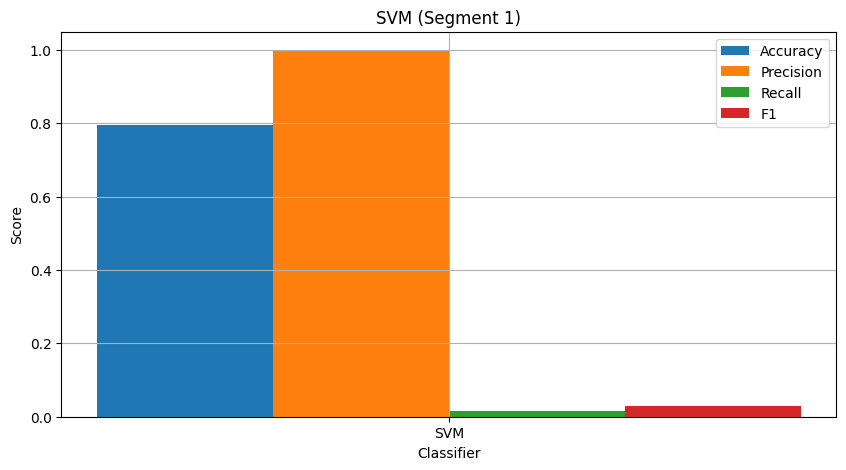


--- SVM (Segment 2) ---
Accuracy:  0.7949
Precision: 1.0000
Recall:    0.0154
F1:        0.0303


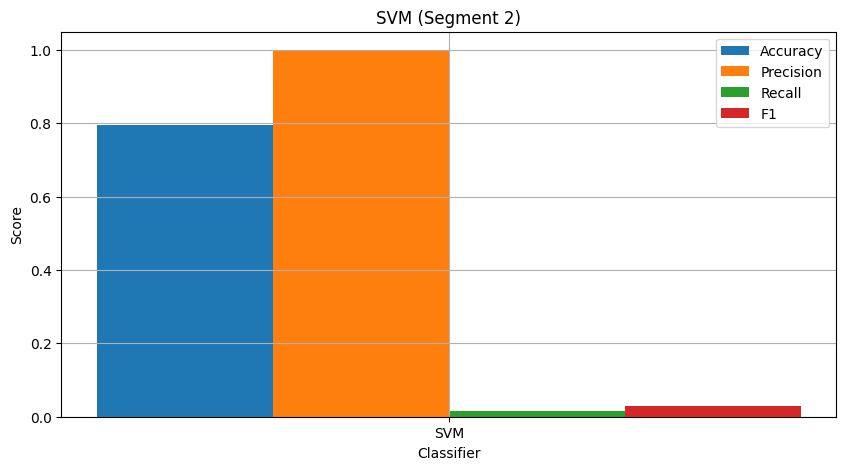


--- SVM (Segment 3) ---
Accuracy:  0.7949
Precision: 1.0000
Recall:    0.0154
F1:        0.0303


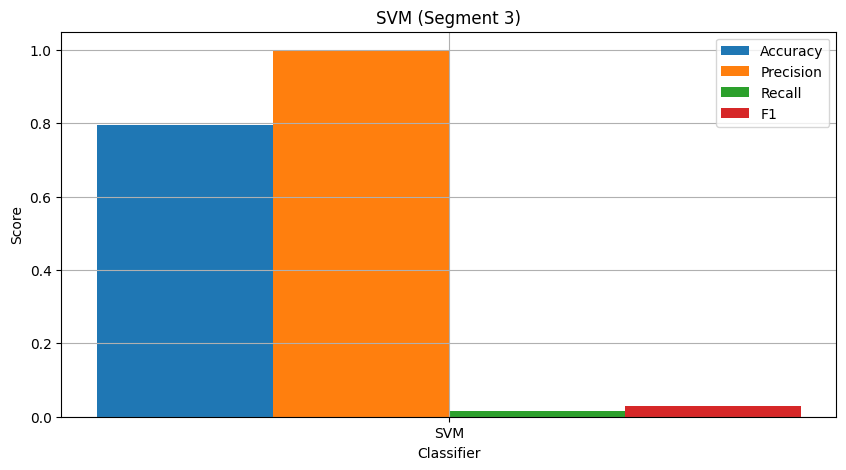

In [32]:
for segment in range(1,4):
    print(f"\n--- SVM (Segment {segment}) ---")

    print(f"Accuracy:  {result[segment-1][2]:.4f}")
    print(f"Precision: {result[segment-1][3]:.4f}")
    print(f"Recall:    {result[segment-1][4]:.4f}")
    print(f"F1:        {result[segment-1][5]:.4f}")

    plot_classifier_metrics(result[segment-1], title=f"SVM (Segment {segment})")

## II. KNN ($\small k$-th Nearest Neighbor)

Classifies each test sample by majority vote among its $5$ nearest neighbors in the training set (Euclidean distance in the $20$-component PCA space).

In [33]:
def run_knn():
    pred = []

    for segment in range(1,4):
        Xtrain, Xtest, Ytrain, Ytest = segment_splits[segment-1]

        model = KNeighborsClassifier(n_neighbors=5)
        model.fit(Xtrain, Ytrain)

        Ypred = model.predict(Xtest)
        acc, prec, rec, f1 = evaluate_metrics(Ytest, Ypred)

        pred.append([segment, 2, acc, prec, rec, f1])

    return pred

result = run_knn()
results.extend(result)


--- KNN (Segment 1) ---
Accuracy:  0.7660
Precision: 0.3750
Recall:    0.1846
F1:        0.2474


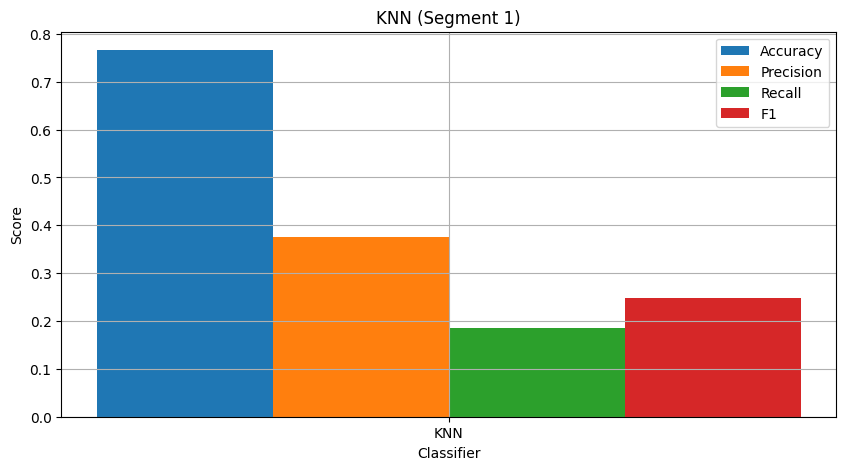


--- KNN (Segment 2) ---
Accuracy:  0.7404
Precision: 0.2778
Recall:    0.1538
F1:        0.1980


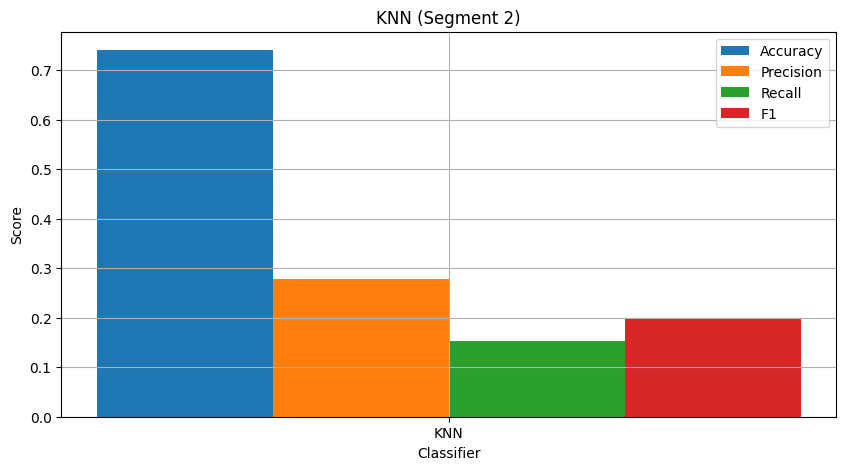


--- KNN (Segment 3) ---
Accuracy:  0.7917
Precision: 0.5000
Recall:    0.1538
F1:        0.2353


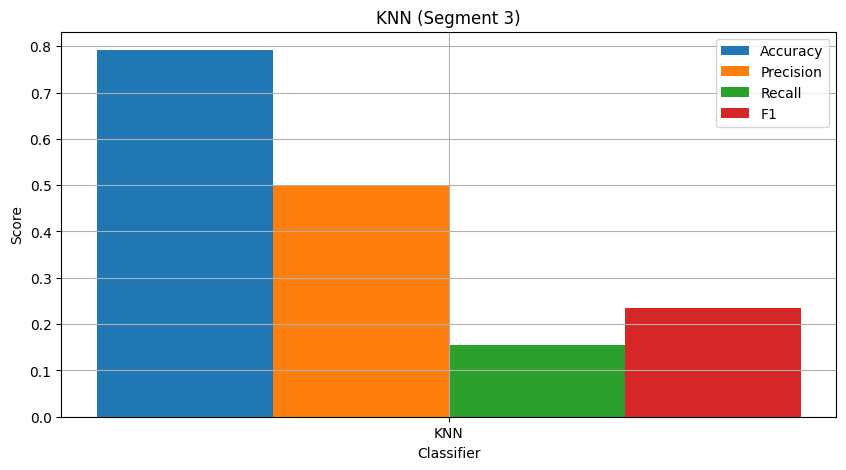

In [34]:
for segment in range(1,4):
    print(f"\n--- KNN (Segment {segment}) ---")

    print(f"Accuracy:  {result[segment-1][2]:.4f}")
    print(f"Precision: {result[segment-1][3]:.4f}")
    print(f"Recall:    {result[segment-1][4]:.4f}")
    print(f"F1:        {result[segment-1][5]:.4f}")

    plot_classifier_metrics(result[segment-1], title=f"KNN (Segment {segment})")

In [35]:
del(result)

## Logistic Regression

Fits a linear decision boundary by modeling the log-odds of the positive class as a linear combination of the input features.

In [36]:
def run_logistic_regression():
    pred = []

    for segment in range(1,4):
        Xtrain, Xtest, Ytrain, Ytest = segment_splits[segment-1]

        model = LogisticRegression(max_iter=5000)
        model.fit(Xtrain, Ytrain)

        Ypred = model.predict(Xtest)
        acc, prec, rec, f1 = evaluate_metrics(Ytest, Ypred)

        pred.append([segment, 3, acc, prec, rec, f1])

    return pred


result = run_logistic_regression()
results.extend(result)


--- Logistic Regression (Segment 1) ---
Accuracy:  0.7853
Precision: 0.3333
Recall:    0.0308
F1:        0.0563


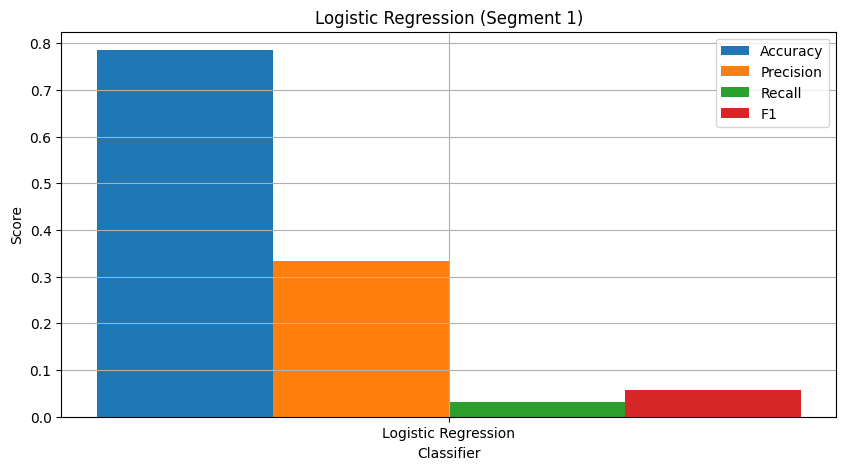


--- Logistic Regression (Segment 2) ---
Accuracy:  0.7917
Precision: 0.5000
Recall:    0.0308
F1:        0.0580


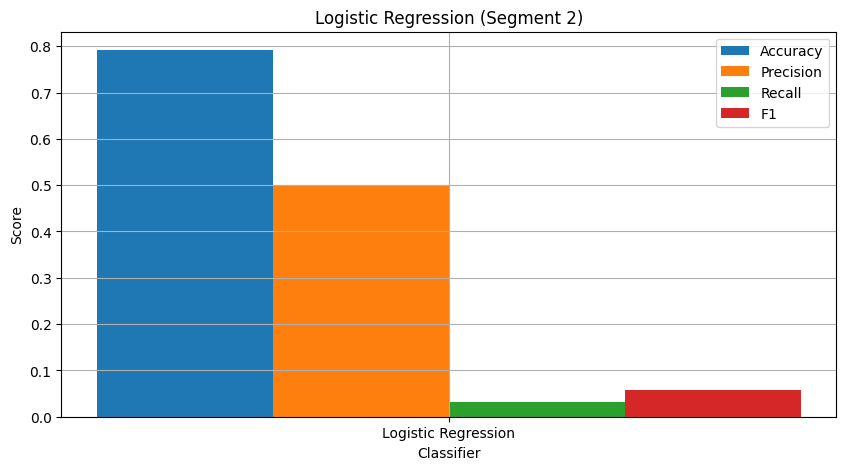


--- Logistic Regression (Segment 3) ---
Accuracy:  0.7853
Precision: 0.3333
Recall:    0.0308
F1:        0.0563


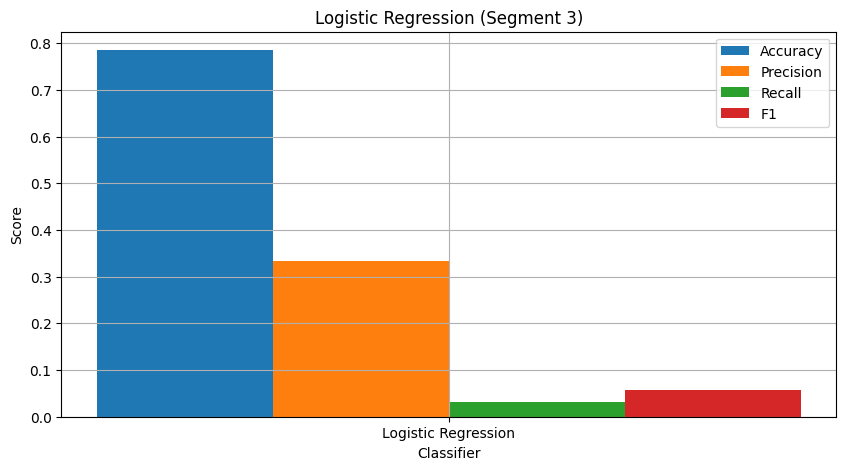

In [37]:
for segment in range(1,4):
    print(f"\n--- Logistic Regression (Segment {segment}) ---")

    print(f"Accuracy:  {result[segment-1][2]:.4f}")
    print(f"Precision: {result[segment-1][3]:.4f}")
    print(f"Recall:    {result[segment-1][4]:.4f}")
    print(f"F1:        {result[segment-1][5]:.4f}")

    plot_classifier_metrics(result[segment-1], title=f"Logistic Regression (Segment {segment})")

In [38]:
del(result)

## Decision Tree (DecTree)

Learns a sequence of feature thresholds that split the training data into increasingly pure groups, forming a tree whose leaves predict a class.

In [39]:
def run_decision_tree():
    pred = []

    for segment in range(1,4):
        Xtrain, Xtest, Ytrain, Ytest = segment_splits[segment-1]
        model = DecisionTreeClassifier()
        model.fit(Xtrain, Ytrain)

        Ypred = model.predict(Xtest)
        acc, prec, rec, f1 = evaluate_metrics(Ytest, Ypred)

        pred.append([segment, 4, acc, prec, rec, f1])

    return pred

result = run_decision_tree()
results.extend(result)


--- DecTree (Segment 1) ---
Accuracy:  0.7019
Precision: 0.2812
Recall:    0.2769
F1:        0.2791


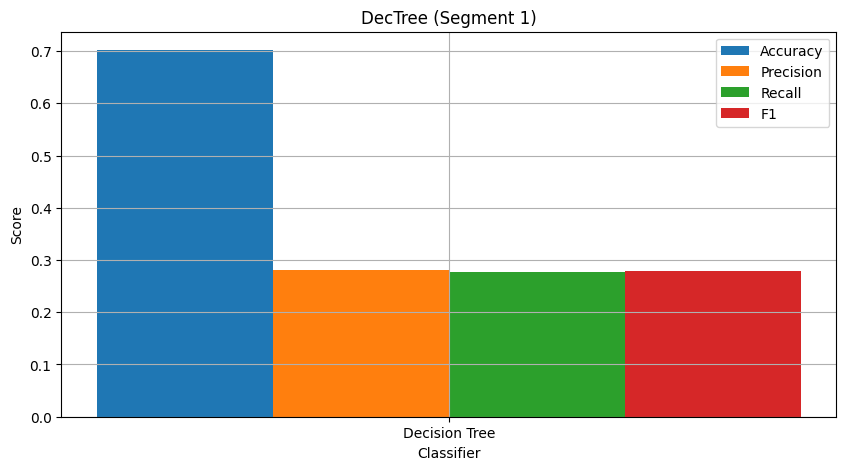


--- DecTree (Segment 2) ---
Accuracy:  0.6699
Precision: 0.2500
Recall:    0.2923
F1:        0.2695


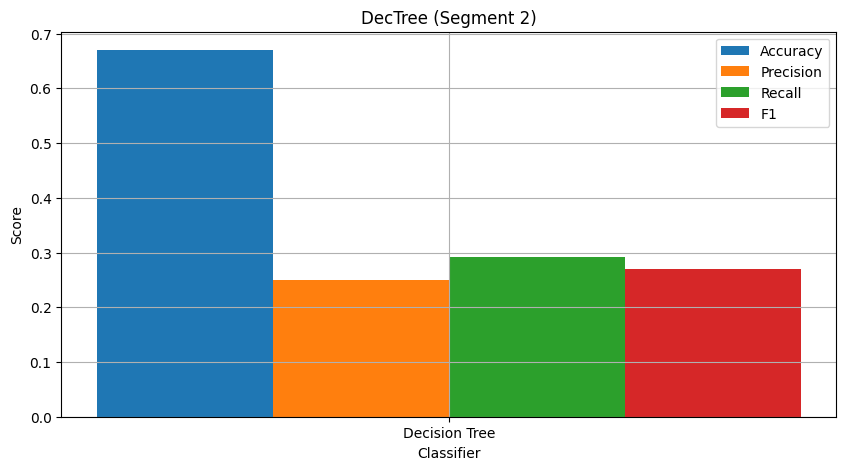


--- DecTree (Segment 3) ---
Accuracy:  0.6827
Precision: 0.2344
Recall:    0.2308
F1:        0.2326


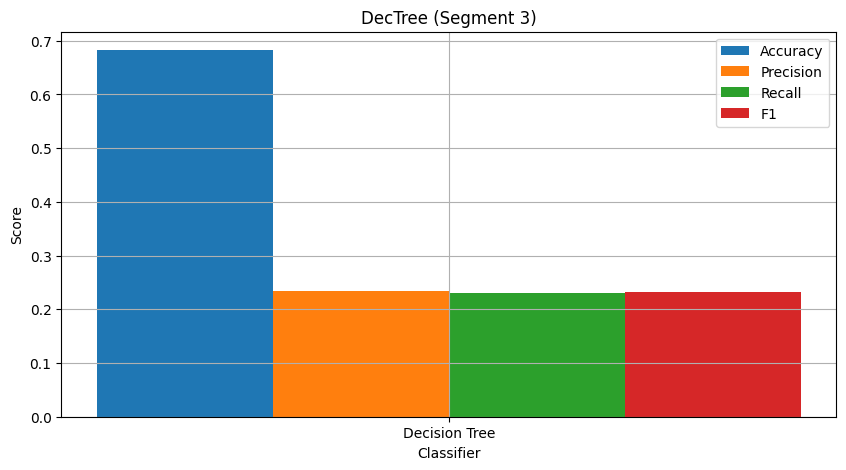

In [40]:
for segment in range(1,4):
    print(f"\n--- DecTree (Segment {segment}) ---")

    print(f"Accuracy:  {result[segment-1][2]:.4f}")
    print(f"Precision: {result[segment-1][3]:.4f}")
    print(f"Recall:    {result[segment-1][4]:.4f}")
    print(f"F1:        {result[segment-1][5]:.4f}")

    plot_classifier_metrics(result[segment-1], title=f"DecTree (Segment {segment})")

In [41]:
del(result)

## LDA (Linear Discriminant Analysis)

 Projects the data onto the direction that best separates the two classes by maximizing between-class variance relative to within-class variance.

In [42]:
def run_lda() -> []:
    pred = []

    for segment in range(1,4):
        Xtrain, Xtest, Ytrain, Ytest = segment_splits[segment-1]

        model = LinearDiscriminantAnalysis()
        model.fit(Xtrain, Ytrain)

        Ypred = model.predict(Xtest)
        acc, prec, rec, f1 = evaluate_metrics(Ytest, Ypred)

        pred.append([segment, 5, acc, prec, rec, f1])

    return pred

result = run_lda()
results.extend(result)


--- LDA (Segment 1) ---
Accuracy:  0.7885
Precision: 0.4286
Recall:    0.0462
F1:        0.0833


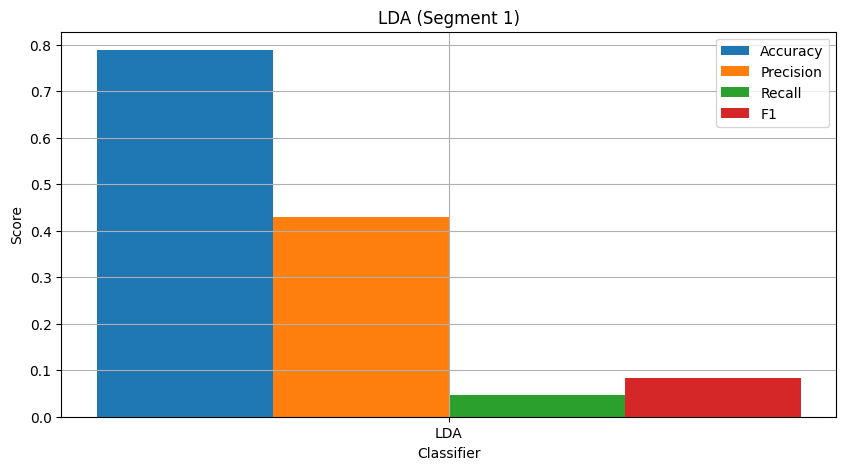


--- LDA (Segment 2) ---
Accuracy:  0.7917
Precision: 0.5000
Recall:    0.0308
F1:        0.0580


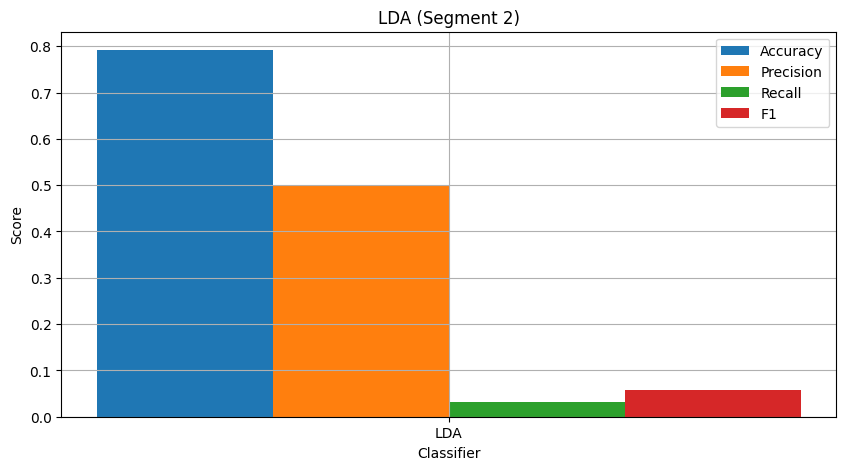


--- LDA (Segment 3) ---
Accuracy:  0.7788
Precision: 0.2500
Recall:    0.0308
F1:        0.0548


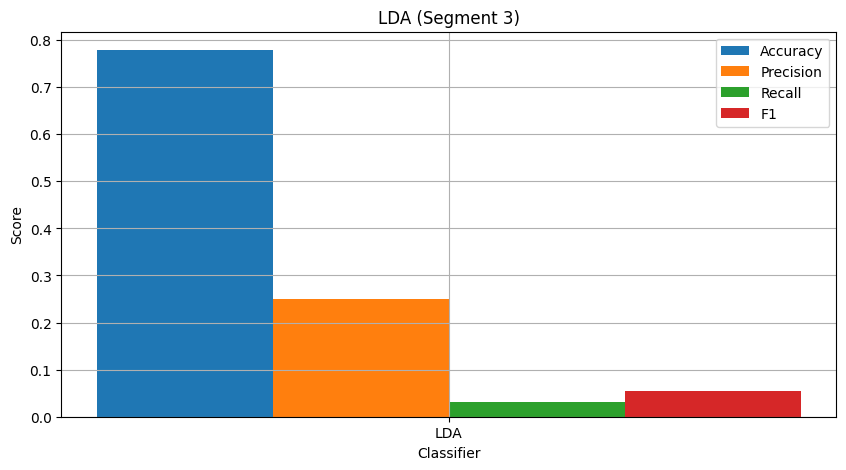

In [43]:
for segment in range(1,4):
    print(f"\n--- LDA (Segment {segment}) ---")

    print(f"Accuracy:  {result[segment-1][2]:.4f}")
    print(f"Precision: {result[segment-1][3]:.4f}")
    print(f"Recall:    {result[segment-1][4]:.4f}")
    print(f"F1:        {result[segment-1][5]:.4f}")

    plot_classifier_metrics(result[segment-1], title=f"LDA (Segment {segment})")

In [44]:
del(result)

# Results
---

Collects every classifier's result from `results` into a single table, reports the best model by F1 score, and plots a bar chart comparing F1 across all of them.

In [45]:
result_table = pd.DataFrame(
    results,
    columns=[
        "Segment",
        "Classifier",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

display_table = result_table.copy()
display_table["Classifier"] = display_table["Classifier"].map(
    lambda classifier_id: classifier_labels[classifier_id - 1]
)

print(display_table)


plot_classifier_metrics(*result_table.values, title="All Classifiers — Summary")

    Segment           Classifier  Accuracy  Precision    Recall        F1
0         1                  SVM  0.794872   1.000000  0.015385  0.030303
1         2                  SVM  0.794872   1.000000  0.015385  0.030303
2         3                  SVM  0.794872   1.000000  0.015385  0.030303
3         1                  KNN  0.766026   0.375000  0.184615  0.247423
4         2                  KNN  0.740385   0.277778  0.153846  0.198020
5         3                  KNN  0.791667   0.500000  0.153846  0.235294
6         1  Logistic Regression  0.785256   0.333333  0.030769  0.056338
7         2  Logistic Regression  0.791667   0.500000  0.030769  0.057971
8         3  Logistic Regression  0.785256   0.333333  0.030769  0.056338
9         1        Decision Tree  0.701923   0.281250  0.276923  0.279070
10        2        Decision Tree  0.669872   0.250000  0.292308  0.269504
11        3        Decision Tree  0.682692   0.234375  0.230769  0.232558
12        1                  LDA  0.78

TypeError: list indices must be integers or slices, not numpy.float64

In [ ]:
print(display_table)

if (len(result_table) > 0):
  # Best model
  best_index = result_table["F1"].idxmax()

  print("\nBEST MODEL\n")
  print(display_table.loc[best_index])
